# Example 3: GNSS Interface Tutorial

This tutorial exercises LuPNT's GNSS file interfaces end to end: it visualizes the GPS, Galileo, and QZSS constellations, inspects transmit-antenna gain patterns, downloads and parses SP3 precise + BRDC broadcast ephemerides with the native C++ loaders (`pnt.Sp3Loader` / `pnt.RinexNavLoader`), applies antenna phase-center-offset corrections, compares broadcast against precise orbits and clocks, and plots the satellites' yaw-steering attitude.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import plotly.graph_objects as go
from datetime import datetime
import os
from pathlib import Path

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

# SP3 / BRDC / ANTEX files are parsed by LuPNT's native C++ loaders
# (pnt.Sp3Loader, pnt.RinexNavLoader, pnt.AntexLoader) -- see the loading cell below.


def find_lupnt_data_dir():
    """Locate the LuPNT_data directory regardless of the notebook's working directory.

    Prefers LUPNT_DATA_PATH (set by the pixi activation / the `lupnt` Jupyter kernel), then
    searches upward from the cwd for `data/LuPNT_data` (repo layout) or a top-level
    `LuPNT_data`, so the notebook works even when launched without the env var. This keeps
    the data at the project root instead of expecting a copy next to this notebook."""
    env = os.environ.get("LUPNT_DATA_PATH")
    if env and Path(env).is_dir():
        return Path(env).resolve()
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base / "data" / "LuPNT_data", base / "LuPNT_data"):
            if candidate.is_dir():
                return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate LuPNT_data. Set LUPNT_DATA_PATH (e.g. run `pixi run install-kernel` "
        "and select the 'LuPNT (pixi)' kernel) or start Jupyter from the repository root."
    )


DATA_DIR = find_lupnt_data_dir()
print(f"Using LuPNT_data: {DATA_DIR}")

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.00][PyLuPNT] Initializing


Using LuPNT_data: /path/to/LuPNT/data/LuPNT_data


---
## Part 1: GNSS constellation visualization

Two-line elements (TLEs) encode an approximate satellite orbit at a reference epoch. LuPNT's `pnt.TLE` class loads the element sets and propagates each satellite to requested epochs.

| System | Typical altitude | Inclination | Period |
|---|---:|---:|---:|
| GPS | 20,200 km | 55 deg | about 12 h |
| Galileo | 23,222 km | 56 deg | about 14 h |
| QZSS | GEO/IGSO/MEO | mixed | about 24 h |

The goal here is not precision orbit determination; it is a quick way to understand constellation geometry and coverage.

In [2]:
# ── Epoch ─────────────────────────────────────────────────────────────────────
T0_TDB = pnt.gregorian_to_time(2025, 1, 1, 0, 0, 0)  # LuPNT internal (≈ TDB)
T0_TAI = pnt.convert_time(T0_TDB, pnt.Time.TDB, pnt.Time.TAI)
T0_TDB_scalar = float(T0_TDB)

TLE_DIR = os.path.join(DATA_DIR, "tle/2025_01_01")


def load_tles(filepath):
    """Parse a 3-line TLE file and return list of pnt.TLE objects."""
    with open(filepath) as f:
        lines = [l.strip() for l in f if l.strip()]
    tles, i = [], 0
    while i + 2 < len(lines):
        if lines[i].startswith("1") or lines[i].startswith("2"):
            i += 1
            continue
        if lines[i + 1].startswith("1") and lines[i + 2].startswith("2"):
            tles.append(pnt.TLE.from_lines(lines[i], lines[i + 1], lines[i + 2]))
            i += 3
        else:
            i += 1
    return tles


gps_tles = load_tles(os.path.join(TLE_DIR, "gps_2025_01_01.txt"))
gal_tles = load_tles(os.path.join(TLE_DIR, "galileo_2025_01_01.txt"))
qzss_tles = load_tles(os.path.join(TLE_DIR, "qzss_2025_01_01.txt"))

print(f"GPS:     {len(gps_tles):2d} sats")
print(f"Galileo: {len(gal_tles):2d} sats")
print(f"QZSS:    {len(qzss_tles):2d} sats")

# tle_to_classical returns COE in ECI (TEME) frame; classical_to_cart → ECI position.
# Convert ECI → ECEF for plotting with the Earth sphere.


def tle_pos_ecef(tle, t_tai):
    """Return ECEF position [m] at given TAI epoch (ECI → ECEF conversion applied)."""
    t_tdb = pnt.convert_time(t_tai, pnt.Time.TAI, pnt.Time.TDB)
    rv_eci = pnt.classical_to_cart(
        np.array(pnt.tle_to_classical(tle, t_tai)), pnt.GM_EARTH
    )
    return pnt.convert_frame(t_tdb, rv_eci, pnt.ECI, pnt.ECEF)[:3]


# Compute snapshot positions at T0 in ECEF
gps_r = np.array([tle_pos_ecef(t, T0_TAI) for t in gps_tles]) / 1e3  # km
gal_r = np.array([tle_pos_ecef(t, T0_TAI) for t in gal_tles]) / 1e3
qzss_r = np.array([tle_pos_ecef(t, T0_TAI) for t in qzss_tles]) / 1e3

R_EARTH_KM = pnt.R_EARTH / 1e3
print(f"\nMean altitude at epoch:")
for name, rr in [("GPS", gps_r), ("Galileo", gal_r), ("QZSS", qzss_r)]:
    alt = np.linalg.norm(rr, axis=1) - R_EARTH_KM
    print(
        f"  {name:<8} {np.mean(alt):.0f} km  (min {np.min(alt):.0f}  max {np.max(alt):.0f})"
    )

GPS:     31 sats
Galileo: 31 sats
QZSS:     4 sats

Mean altitude at epoch:
  GPS      20143 km  (min 19887  max 20780)
  Galileo  23380 km  (min 23208  max 25728)
  QZSS     36622 km  (min 35653  max 38902)


## Orbit visualization

Each satellite is propagated for two days from the TLE epoch. The 3-D plot shows the orbital shells, and the ground-track map shows how inclination and orbital period turn into Earth coverage.

Computing trajectory for 2 days (1-min cadence)…


Done.


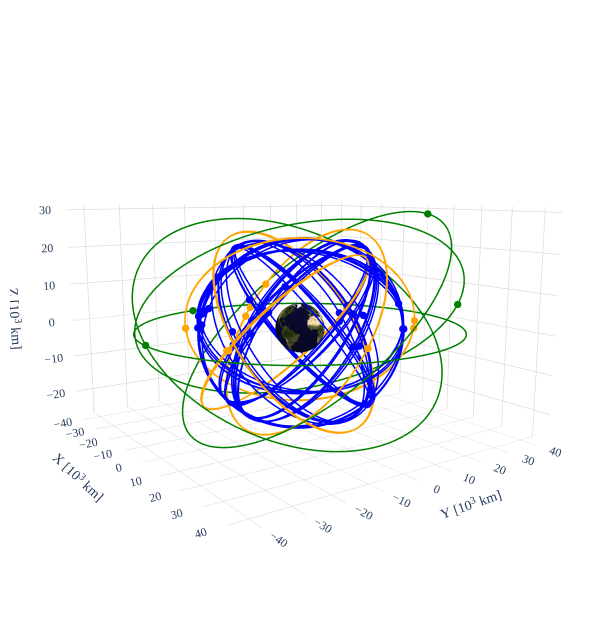

In [3]:
# ── 7-day time grid (30-min intervals) ────────────────────────────────────────
DT_TRACK = 1 * 60  # 1-min cadence [s]
T_SPAN = 2 * 24 * 3600  # 7 days [s]
t_arr = T0_TAI + np.arange(0, T_SPAN + DT_TRACK, DT_TRACK)  # [N] TAI
t_tdb_arr = pnt.convert_time(t_arr, pnt.Time.TAI, pnt.Time.TDB)  # [N] TDB

dyn = pnt.CartesianTwoBodyDynamics(pnt.GM_EARTH)
dyn.set_integrator(pnt.IntegratorType.RKF45)
dyn.set_integrator_params(pnt.IntegratorParams(max_iter=20, abstol=1e-3, reltol=1e-9))


def get_trajectory(tle):
    """Propagate TLE for 2 days and return (lat, lon) arrays [deg]."""
    # tle_to_classical → COE in ECI; classical_to_cart → ECI state directly
    coe = np.array(pnt.tle_to_classical(tle, T0_TAI))
    rv0_eci = pnt.classical_to_cart(coe, pnt.GM_EARTH)  # already in ECI
    # propagate: t_arr[0] == T0_TAI  (signature: propagate(x0, tfs))
    rv_eci = dyn.propagate(rv0_eci, t_arr)  # [N×6] ECI
    return rv_eci


print("Computing trajectory for 2 days (1-min cadence)…")
gps_traj = np.array([get_trajectory(t) for t in gps_tles])
gal_traj = np.array([get_trajectory(t) for t in gal_tles])
qzss_traj = np.array([get_trajectory(t) for t in qzss_tles])
print("Done.")

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.EARTH)
pnt.plot.plot_orbits(fig, gps_traj, t=0, color="blue")
pnt.plot.plot_orbits(fig, gal_traj, t=0, color="orange")
pnt.plot.plot_orbits(fig, qzss_traj, t=0, color="green")
pnt.plot.set_view(fig, azimuth=-35, elevation=10, zoom=2.5)
embed_plotly(fig, "ex3_gnss_constellation")

---
## Part 2: Satellite antenna gain patterns

A GNSS transmitter is usually designed to illuminate Earth, not the Moon. The received power at lunar distance therefore depends strongly on off-boresight angle. If $\theta=0$ is nadir, the antenna table gives transmit gain $G_T(\theta,\phi)$, which feeds the link budget through

$$
C/N_0 \propto \mathrm{EIRP}(\theta,\phi)-L_{fs}+G_R-10\log_{10}(kT_{sys}).
$$

LuPNT's `pnt.Antenna` class loads pattern tables from `data/LuPNT_data/antenna/` for representative GPS, Galileo, and QZSS signals.

## GPS block antennas: 2-D polar comparison

The polar plots compare block-specific GPS transmit patterns. Main-lobe behavior is near the center; sidelobes appear at larger off-boresight angles and are the important region for lunar receivers.

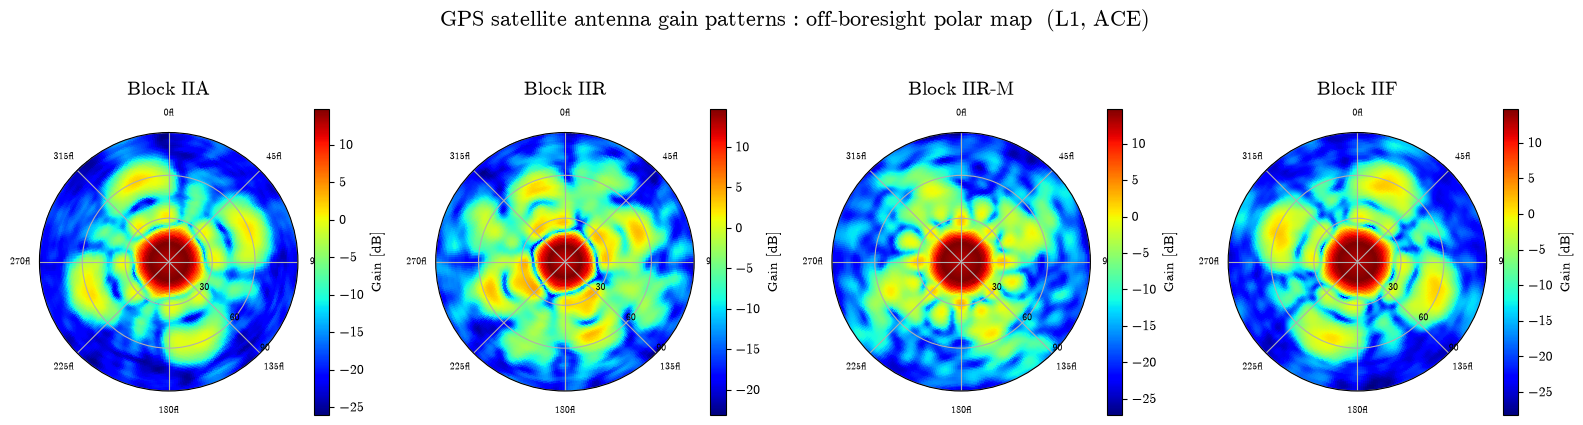


Block          Peak gain [dB]   At phi [deg]
--------------------------------------------
Block IIA                14.8           12.0
Block IIR                14.7           10.0
Block IIR-M              14.8           12.0
Block IIF                14.8           12.0


In [4]:
def plot_antenna_2d_polar(ax, antenna, name=None, cmap="jet"):
    """
    2-D polar gain map: radius = off-boresight angle (0° center → 90° edge),
    azimuth = antenna azimuth angle, color = gain [dB].
    """
    phi = np.array(antenna.get_phi_vector())  # (N_phi,)   0-90 deg
    theta = np.array(antenna.get_theta_vector())  # (N_theta,) 0-360 deg
    gain = np.array(antenna.get_gain_matrix())  # (N_phi, N_theta)

    T, P = np.meshgrid(np.radians(theta), phi)  # shapes (N_phi, N_theta)
    mesh = ax.pcolormesh(
        T,
        P,
        gain,
        cmap=cmap,
        shading="auto",
        vmin=np.nanmin(gain),
        vmax=np.nanmax(gain),
    )
    ax.set_theta_zero_location("N")  # 0° azimuth at top
    ax.set_theta_direction(-1)  # clockwise azimuth
    ax.set_rmax(90)
    ax.set_rticks([30, 60, 90])
    ax.set_rlabel_position(135)
    ax.tick_params(labelsize=7)
    ax.set_title(name or antenna.name, pad=10, fontsize=14)
    return mesh


gps_blocks = {
    "Block IIA": "Block-IIA_ACE",
    "Block IIR": "Block-IIR_ACE",
    "Block IIR-M": "Block-IIR-M_ACE",
    "Block IIF": "Block-IIF_ACE",
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), subplot_kw=dict(projection="polar"))
meshes = []
for ax, (label, name) in zip(axes, gps_blocks.items()):
    meshes.append(plot_antenna_2d_polar(ax, pnt.Antenna(name), name=label))
    cbar = fig.colorbar(meshes[-1], ax=ax, shrink=0.8)
    cbar.set_label("Gain [dB]", fontsize=10)

plt.suptitle(
    "GPS satellite antenna gain patterns : off-boresight polar map  (L1, ACE)",
    y=1.02,
    fontsize=16,
)
plt.tight_layout()
plt.show()

print(f'\n{"Block":<12}  {"Peak gain [dB]":>15}  {"At phi [deg]":>13}')
print("-" * 44)
for label, name in gps_blocks.items():
    a = pnt.Antenna(name)
    phi = np.array(a.get_phi_vector())
    gm = np.array(a.get_gain_matrix())
    g1d = gm[:, 0]
    print(f"{label:<12}  {np.max(g1d):>15.1f}  {phi[np.argmax(g1d)]:>13.1f}")

## GPS, Galileo, and QZSS comparison

This panel puts representative transmit patterns from multiple constellations on the same scale. It is a quick way to see which signals remain useful outside the Earth-facing main beam.

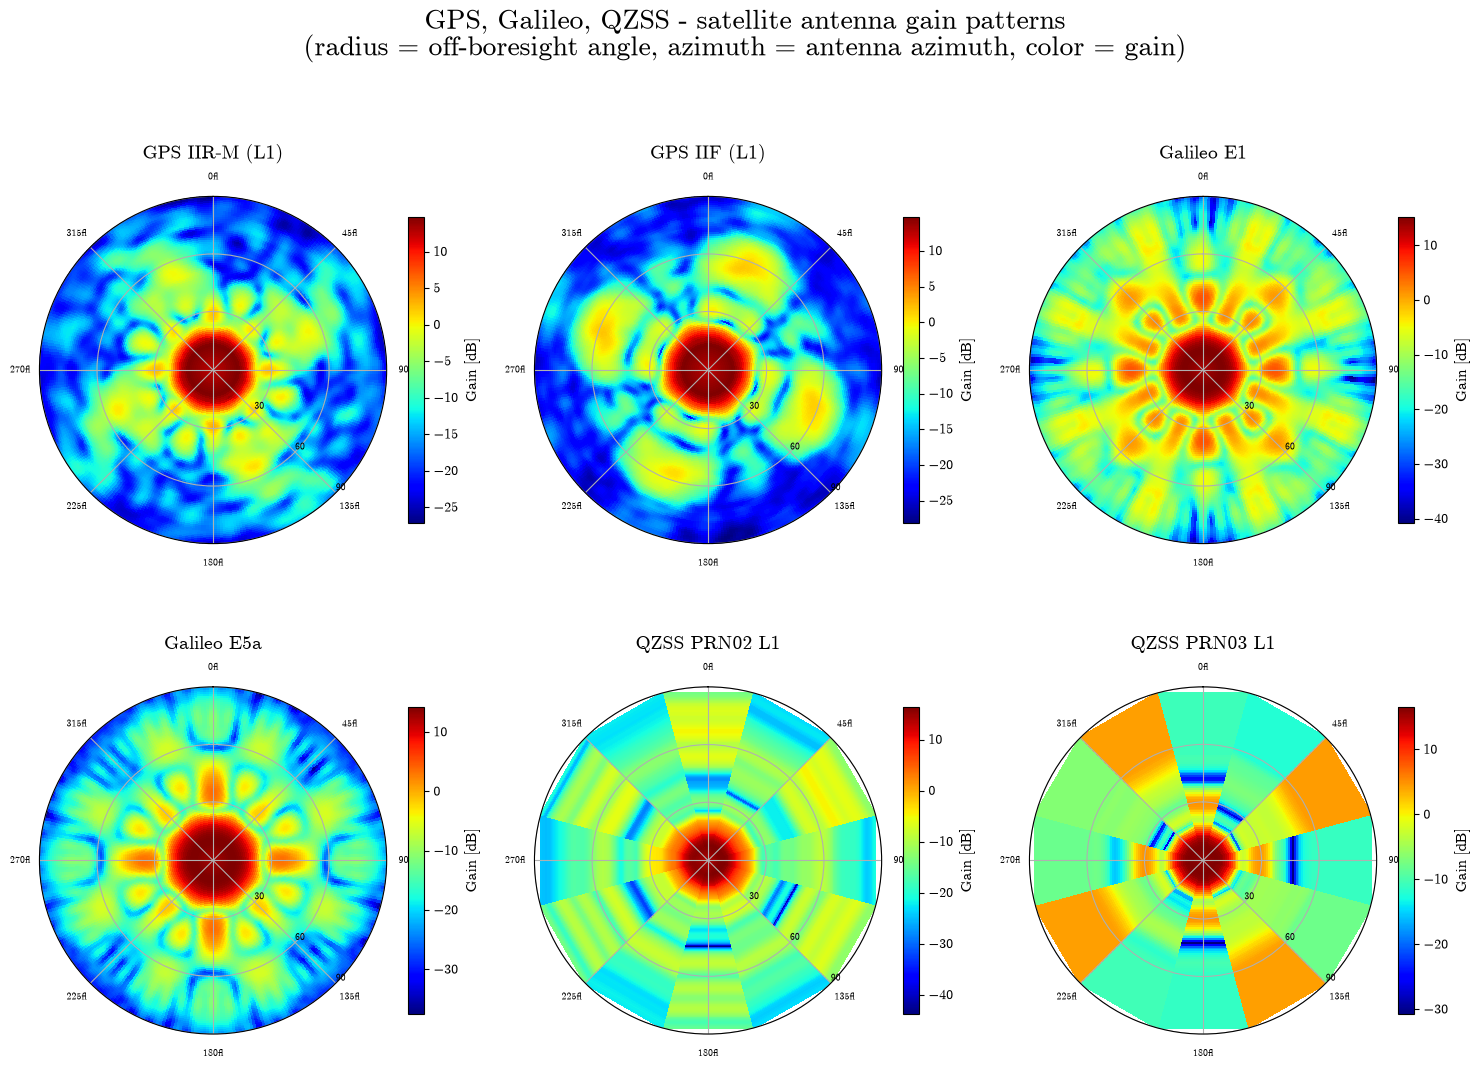

In [5]:
multi = [
    ("GPS IIR-M (L1)", "Block-IIR-M_ACE"),
    ("GPS IIF (L1)", "Block-IIF_ACE"),
    ("Galileo E1", "Galileo_E1"),
    ("Galileo E5a", "Galileo_E5a"),
    ("QZSS PRN02 L1", "QZSS_02_L1"),
    ("QZSS PRN03 L1", "QZSS_03_L1"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 11), subplot_kw=dict(projection="polar"))
meshes = []
for ax, (label, name) in zip(axes.flatten(), multi):
    meshes.append(plot_antenna_2d_polar(ax, pnt.Antenna(name), name=label))
    cbar = fig.colorbar(meshes[-1], ax=ax, shrink=0.6)
    cbar.set_label("Gain [dB]", fontsize=11)

plt.suptitle(
    "GPS, Galileo, QZSS - satellite antenna gain patterns\n"
    "(radius = off-boresight angle, azimuth = antenna azimuth, color = gain)",
    y=1.02,
    fontsize=20,
)
plt.tight_layout()
plt.show()

## 3-D gain pattern: GPS Block IIF

The 3-D rendering wraps the gain table around the antenna boresight. This view helps connect a scalar off-boresight plot to the actual direction-dependent transmit pattern used in link-budget calculations.

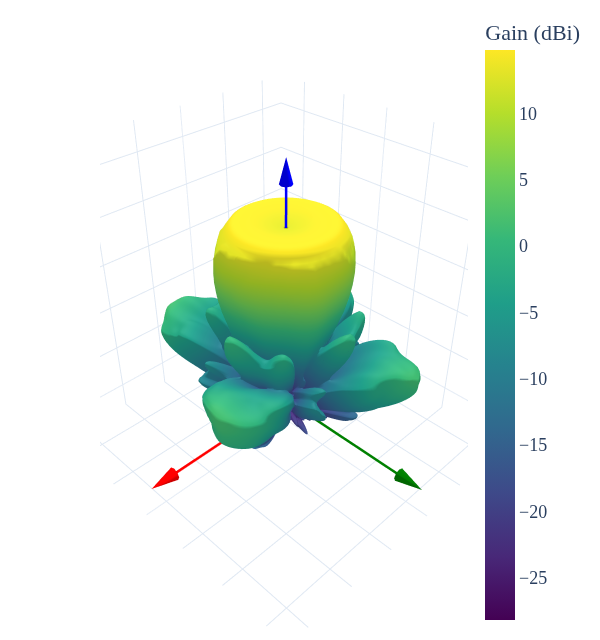

In [6]:
antenna = pnt.Antenna("Block-IIF_ACE")
fig = pnt.plot.plot_antenna_gain_pattern(antenna=antenna)
embed_plotly(fig, "ex3_broadcast_precise")

---
## Part 3: Broadcast versus precise ephemeris

Navigation receivers normally use broadcast ephemerides because they are available in real time. Precise products are delayed, but they provide a reference for analysis.

| Product | Typical latency | Orbit accuracy | Clock accuracy |
|---|---:|---:|---:|
| Broadcast RINEX | real time | about 1 m | several ns |
| IGS/COD MGEX SP3 final | about 2 weeks | cm level | sub-ns |

To compare them consistently, we also correct for the antenna phase-center offset (PCO). SP3 products are commonly referenced to the satellite center of mass, while broadcast models are used at the antenna phase center:

$$
\mathbf r_{APC}=\mathbf r_{CoM}+R_{NEU\to ECEF}\,\mathbf{PCO}_{NEU}.
$$

Differences are decomposed in the RTN frame so radial, along-track, and cross-track behavior can be interpreted separately.

## Download and load SP3 and BRDC files

This cell downloads the precise (SP3) and broadcast (BRDC) products for the selected days from NASA CDDIS and parses them with the C++ loaders. Downloaded files are cached under `output/gnss_files/`, so re-runs need no network access.

In [7]:
from datetime import datetime, timedelta

# ── Comparison window ─────────────────────────────────────────────────────────
# ex3 downloads the daily COD MGEX final SP3 + multi-GNSS BRDC broadcast products
# straight from NASA CDDIS using LuPNT's C++ loaders -- this doubles as a check
# that your Earthdata Login is configured. Downloads need credentials in
# ~/.netrc (machine urs.earthdata.nasa.gov) or the EARTHDATA_USERNAME /
# EARTHDATA_PASSWORD environment variables; see
# https://cddis.nasa.gov/Data_and_Derived_Products/CDDIS_Archive_Access.html
# Files are cached under output/gnss_files/{sp3,brdc}, so re-runs skip the fetch.
START_DT = datetime(2026, 1, 1)  # UTC start date
SIM_DAYS = 3


def _day_epoch_tai(dt):
    """Mid-day TAI epoch for a calendar day (used to pick that day's product)."""
    t_tdb = pnt.gregorian_to_time(dt.year, dt.month, dt.day, 12, 0, 0)
    return pnt.convert_time(t_tdb, pnt.Time.TDB, pnt.Time.TAI)


# One daily product per day spanning the window, plus a one-day lead-in margin so the interpolators have data at the endpoints.
window_days = [START_DT + timedelta(days=d) for d in range(-1, SIM_DAYS + 1)]

# ── SP3 precise orbits (COD MGEX final, 5-min) + BRDC broadcast ephemeris ─────
print(
    f"Downloading SP3 + BRDC from CDDIS for {SIM_DAYS}-day window starting {START_DT.date()}…"
)
sp3_paths, brdc_paths = [], []
for dt in window_days:
    te = _day_epoch_tai(dt)
    sp3_paths.append(pnt.Sp3Loader.download_file_for_epoch(te, pnt.Time.TAI))
    brdc_paths.append(pnt.RinexNavLoader.download_file_for_epoch(te, pnt.Time.TAI))

# LuPNT C++ Sp3Loader / RinexNavLoader parse the downloaded files.
sp3 = pnt.Sp3Loader(sp3_paths)
brdc = pnt.RinexNavLoader(brdc_paths)

sats_sp3 = sp3.get_satellites()
sats_brdc = brdc.get_satellites()
print(f"  SP3  satellites: {len(sats_sp3)}  |  BRDC satellites: {len(sats_brdc)}")
gps_sp3 = sorted(int(s[1:]) for s in sats_sp3 if s.startswith("G"))
gal_sp3 = sorted(int(s[1:]) for s in sats_sp3 if s.startswith("E"))
gps_brdc = sorted(int(s[1:]) for s in sats_brdc if s.startswith("G"))
gal_brdc = sorted(int(s[1:]) for s in sats_brdc if s.startswith("E"))
print(f"  GPS PRNs in SP3: {gps_sp3}")
print(f"  Galileo PRNs in SP3: {gal_sp3}")
print(f"  GPS PRNs in BRDC: {gps_brdc}")
print(f"  Galileo PRNs in BRDC: {gal_brdc}")

# ── Select up to 5 common GPS / Galileo PRNs ─────────────────────────────────
COMMON_PRNS_GPS = sorted(set(gps_sp3) & set(gps_brdc))[:5]
COMMON_PRNS_GAL = sorted(set(gal_sp3) & set(gal_brdc))[:5]
print(f'\nSelected GPS PRNs for comparison: {[f"G{p:02d}" for p in COMMON_PRNS_GPS]}')
print(f'Selected Galileo PRNs for comparison: {[f"E{p:02d}" for p in COMMON_PRNS_GAL]}')

  SP3  satellites: 123  |  BRDC satellites: 115
  GPS PRNs in SP3: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
  Galileo PRNs in SP3: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19, 21, 23, 25, 26, 27, 29, 30, 31, 33, 34, 36]
  GPS PRNs in BRDC: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
  Galileo PRNs in BRDC: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19, 21, 23, 25, 26, 27, 29, 30, 31, 33, 34, 36]

Selected GPS PRNs for comparison: ['G01', 'G02', 'G03', 'G04', 'G05']
Selected Galileo PRNs for comparison: ['E02', 'E03', 'E04', 'E05', 'E06']


In [8]:
# ── ANTEX PCO (LuPNT C++ AntexLoader) ─────────────────────────────────────────
antex = pnt.AntexLoader(os.path.join(DATA_DIR, "gnss/igs20.atx"))

# The C++ loader is time-dependent (ANTEX validity blocks), so PCOs are queried at
# a TAI epoch -- use mid-day of the window's start date.
T_PCO_TDB = pnt.gregorian_to_time(START_DT.year, START_DT.month, START_DT.day, 12, 0, 0)
T_PCO_TAI = pnt.convert_time(T_PCO_TDB, pnt.Time.TDB, pnt.Time.TAI)

print("GPS L1 phase-centre offsets (IGS20 ANTEX):")
print(f'{"PRN":>5}  {"N [mm]":>8}  {"E [mm]":>8}  {"U [mm]":>8}')
print("-" * 36)
for prn in COMMON_PRNS_GPS:
    pco = np.asarray(antex.get_pco(pnt.GnssConst.GPS, prn, pnt.GnssFreq.L1, T_PCO_TAI))
    print(f"G{prn:02d}   {pco[0]*1e3:>8.1f}  {pco[1]*1e3:>8.1f}  {pco[2]*1e3:>8.1f}")


print("\nGalileo E1 phase-centre offsets (IGS20 ANTEX):")
print(f'{"PRN":>5}  {"N [mm]":>8}  {"E [mm]":>8}  {"U [mm]":>8}')
print("-" * 36)
for prn in COMMON_PRNS_GAL:
    pco = np.asarray(
        antex.get_pco(pnt.GnssConst.GALILEO, prn, pnt.GnssFreq.E1, T_PCO_TAI)
    )
    print(f"E{prn:02d}   {pco[0]*1e3:>8.1f}  {pco[1]*1e3:>8.1f}  {pco[2]*1e3:>8.1f}")

GPS L1 phase-centre offsets (IGS20 ANTEX):
  PRN    N [mm]    E [mm]    U [mm]
------------------------------------
G01      -65.9      20.4    1185.8
G02        1.3      -1.1     681.9
G03      394.0       0.0    1482.3
G04      -59.9      17.5    1179.8
G05       -3.3      -0.3     742.6

Galileo E1 phase-centre offsets (IGS20 ANTEX):
  PRN    N [mm]    E [mm]    U [mm]
------------------------------------
E02      121.3      -9.1     881.8
E03      116.0      -9.2     892.8
E04      122.4      -9.7     890.5
E05      121.4      -9.4     912.9
E06      118.7      -9.5     897.6


## Query SP3 and BRDC positions

Positions and clocks are evaluated at 15-minute intervals. SP3 states come from interpolation over the precise product; BRDC states come from the nearest navigation message and its Keplerian-plus-harmonic broadcast model.

In [9]:
# ── Query epochs: 15-min cadence over the full window ────────────────────────
T_START_TDB = pnt.gregorian_to_time(
    START_DT.year, START_DT.month, START_DT.day, 0, 0, 0
)
T_START_TAI = pnt.convert_time(T_START_TDB, pnt.Time.TDB, pnt.Time.TAI)
DT_Q = 15 * 60  # 15-min cadence [s]
N_Q = SIM_DAYS * 24 * 4 + 1  # e.g. 3×96 + 1 = 289 epochs
t_q_tai = T_START_TAI + np.arange(N_Q) * DT_Q
t_q_tdb = pnt.convert_time(t_q_tai, pnt.Time.TAI, pnt.Time.TDB)
t_hours = np.arange(N_Q) * DT_Q / 3600.0

print(f"Query grid: {N_Q} epochs  |  span: {t_hours[-1]:.1f} h  ({SIM_DAYS} days)")


def query_posvelclock_eci(loader, sat_id, t_tai_arr, t_tdb_arr):
    """Evaluate a C++ SP3/RINEX loader over a time grid.

    The C++ loaders are scalar-in-time and return ECEF states + a scalar clock, so
    we loop the query and rotate ECEF → ECI once (vectorised). Epochs the loader
    can't cover (satellite absent / out of span) are returned as NaN."""
    n = len(t_tai_arr)
    rv_ecef = np.full((n, 6), np.nan)
    clk = np.full(n, np.nan)
    for k in range(n):
        try:
            rv, c = loader.get_pos_vel_clock(sat_id, float(t_tai_arr[k]))
            rv_ecef[k] = np.asarray(rv, dtype=float)
            clk[k] = float(c)
        except RuntimeError:
            pass  # leave NaN for uncovered epochs
    rv_eci = np.asarray(pnt.convert_frame(t_tdb_arr, rv_ecef, pnt.ECEF, pnt.ECI))
    return rv_eci, clk


results = {}

for prn in COMMON_PRNS_GPS:
    tag = f"G{prn:02d}"
    print(f"Processing {tag}")
    # SP3: centre-of-mass in ECI [m, m/s] + clock [s]
    rv_sp3, clk_sp3 = query_posvelclock_eci(sp3, tag, t_q_tai, t_q_tdb)
    # BRDC: antenna phase-centre in ECI [m, m/s] + clock [s]
    rv_brdc, clk_brdc = query_posvelclock_eci(brdc, tag, t_q_tai, t_q_tdb)
    results[tag] = dict(
        rv_sp3=rv_sp3, rv_brdc=rv_brdc, clk_sp3=clk_sp3, clk_brdc=clk_brdc
    )

for prn in COMMON_PRNS_GAL:
    tag = f"E{prn:02d}"
    print(f"Processing {tag}")
    rv_sp3, clk_sp3 = query_posvelclock_eci(sp3, tag, t_q_tai, t_q_tdb)
    rv_brdc, clk_brdc = query_posvelclock_eci(brdc, tag, t_q_tai, t_q_tdb)
    results[tag] = dict(
        rv_sp3=rv_sp3, rv_brdc=rv_brdc, clk_sp3=clk_sp3, clk_brdc=clk_brdc
    )

print(f"\nPosition arrays shape: {rv_sp3.shape}   (N_epochs x 6)")

Query grid: 289 epochs  |  span: 72.0 h  (3 days)
Processing G01
Processing G02
Processing G03
Processing G04
Processing G05
Processing E02
Processing E03
Processing E04
Processing E05
Processing E06

Position arrays shape: (289, 6)   (N_epochs x 6)


## Apply PCO corrections and rotate into RTN

`AntexLoader.apply_pco_correction_ecef` (C++) builds the satellite body-frame rotation from the nadir direction and the Sun direction and applies the NEU phase-centre offset in ECEF. After applying PCO, we compare broadcast and precise states in the local RTN frame of the broadcast orbit.

Applying PCO corrections…
  G01… 

R std=0.14 m  T std=0.65 m  N std=0.24 m
  G02… 

R std=0.19 m  T std=0.59 m  N std=0.21 m


  G03… 

R std=0.18 m  T std=0.59 m  N std=0.25 m
  G04… 

...

R std=0.12 m  T std=0.29 m  N std=0.11 m
  E03… 

R std=0.16 m  T std=0.26 m  N std=0.15 m
  E04… 

R std=0.16 m  T std=0.35 m  N std=0.18 m
  E05… 

R std=0.15 m  T std=0.26 m  N std=0.12 m
  E06… 

R std=0.14 m  T std=0.35 m  N std=0.20 m


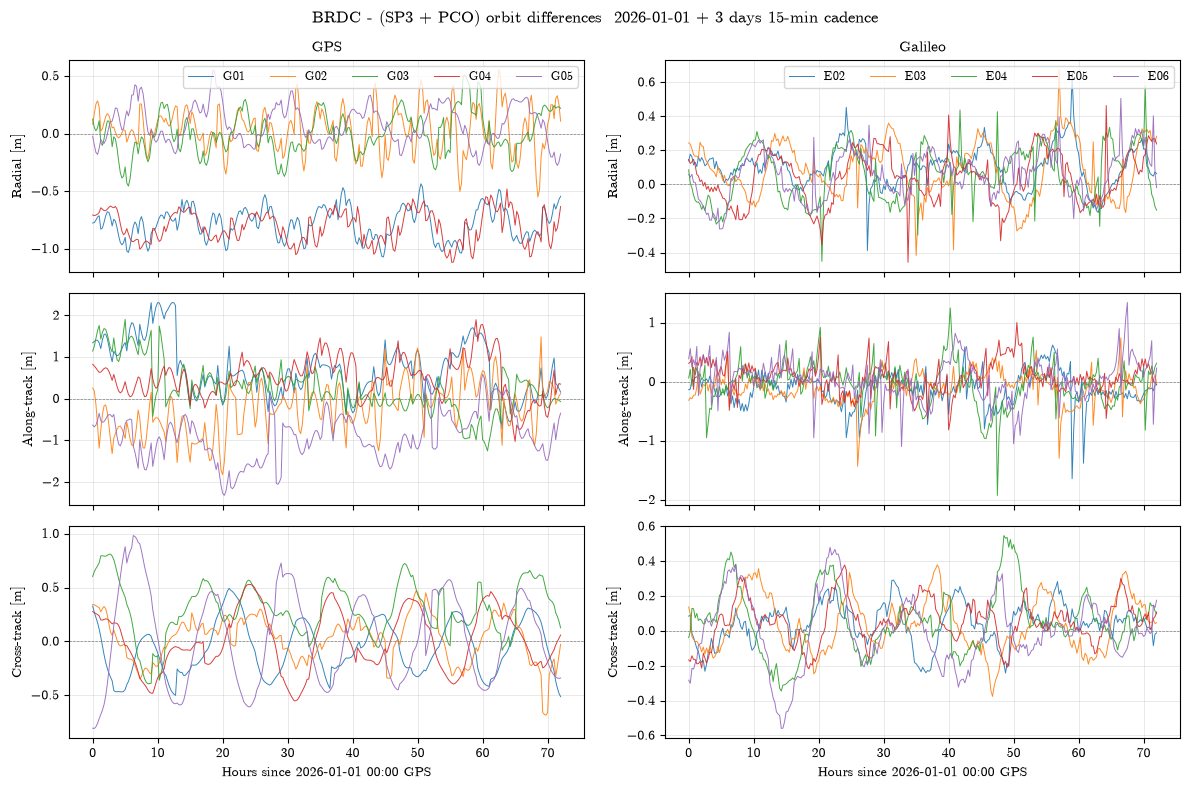

In [10]:
def apply_pco_correction(tag, rv_sp3_eci, t_tai_arr, t_tdb_arr):
    """
    Shift SP3 CoM → APC positions using IGS20 ANTEX PCOs (GPS L1 / Galileo E1).
    Returns corrected APC positions in ECI [m], shape (N, 3).

    Uses the C++ AntexLoader: get_pco() returns the NEU offset [m] and
    apply_pco_correction_ecef() rotates it into ECEF (satellite yaw-steering
    attitude from the Sun direction) and adds it to the CoM position.
    """
    prn = int(tag[1:])
    const = pnt.GnssConst.GPS if tag[0] == "G" else pnt.GnssConst.GALILEO
    freq = pnt.GnssFreq.L1 if tag[0] == "G" else pnt.GnssFreq.E1

    # 1. SP3 ECI → ECEF
    rv_sp3_ecef = np.asarray(
        pnt.convert_frame(t_tdb_arr, rv_sp3_eci, pnt.ECI, pnt.ECEF)
    )
    r_com_ecef = rv_sp3_ecef[:, :3]

    r_apc_ecef = np.empty_like(r_com_ecef)
    for k in range(len(t_tai_arr)):
        t_k = float(t_tai_arr[k])
        # 2. NEU phase-centre offset [m] at epoch k
        pco_neu = np.asarray(antex.get_pco(const, prn, freq, t_k))
        # 3. CoM + PCO in ECEF (rotation applied inside the C++ helper)
        r_apc_ecef[k] = np.asarray(
            pnt.AntexLoader.apply_pco_correction_ecef(t_k, r_com_ecef[k], pco_neu)
        )

    # 4. APC ECEF → ECI
    rv_apc_ecef = np.hstack([r_apc_ecef, rv_sp3_ecef[:, 3:]])
    rv_apc_eci = np.asarray(
        pnt.convert_frame(t_tdb_arr, rv_apc_ecef, pnt.ECEF, pnt.ECI)
    )
    return rv_apc_eci[:, :3]


def rtn_decompose(r_ref, v_ref, dr):
    """
    Decompose position difference dr (N x 3 ECI) into RTN components.
    Returns (R, T, N) each of shape (N,) in metres.
    """
    r_hat = r_ref / np.linalg.norm(r_ref, axis=1, keepdims=True)
    h = np.cross(r_ref, v_ref)
    n_hat = h / np.linalg.norm(h, axis=1, keepdims=True)
    t_hat = np.cross(n_hat, r_hat)
    R = (dr * r_hat).sum(axis=1)
    T = (dr * t_hat).sum(axis=1)
    N = (dr * n_hat).sum(axis=1)
    return R, T, N


# ── Compute and plot RTN differences ─────────────────────────────────────────
print("Applying PCO corrections…")
rtn_all = {}
COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

END_DT = START_DT.strftime("%Y-%m-%d")
days_label = f'{START_DT.strftime("%Y-%m-%d")} + {SIM_DAYS} days'

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
fig.suptitle(
    f"BRDC - (SP3 + PCO) orbit differences  {days_label} 15-min cadence", fontsize=12
)

for i, (tag, d) in enumerate(results.items()):
    if tag.startswith("G"):
        axes_tag = axes[:, 0]  # GPS in left column
    else:
        axes_tag = axes[:, 1]  # Galileo in right column

    clr = COLORS[i % len(COLORS)]
    print(f"  {tag}…", end=" ", flush=True)

    r_sp3_apc = apply_pco_correction(tag, d["rv_sp3"], t_q_tai, t_q_tdb)

    r_brdc = d["rv_brdc"][:, :3]
    v_brdc = d["rv_brdc"][:, 3:]
    dr = r_brdc - r_sp3_apc

    R, T, N = rtn_decompose(r_brdc, v_brdc, dr)
    rtn_all[tag] = (R, T, N)
    print(f"R std={np.std(R):.2f} m  T std={np.std(T):.2f} m  N std={np.std(N):.2f} m")

    for ax, comp in zip(axes_tag, [R, T, N]):
        ax.plot(
            t_hours,
            comp,
            lw=0.7,
            color=clr,
            label=tag if ax is axes[0, 0] or ax is axes[0, 1] else None,
            alpha=0.9,
        )

for col in range(2):
    for ax, ylabel in zip(
        axes[:, col], ["Radial [m]", "Along-track [m]", "Cross-track [m]"]
    ):
        ax.set_ylabel(ylabel)
        ax.axhline(0, color="gray", lw=0.5, ls="--")
        ax.grid(True, lw=0.4, alpha=0.5)

    if col == 0:
        axes[0, col].set_title("GPS", fontsize=11)
    else:
        axes[0, col].set_title("Galileo", fontsize=11)

    axes[0, col].legend(loc="upper right", fontsize=9, ncol=len(results))
    axes[-1, col].set_xlabel(f'Hours since {START_DT.strftime("%Y-%m-%d")} 00:00 GPS')

plt.tight_layout()
plt.show()

## Satellite clock comparison

The broadcast clock polynomial is compared with the SP3 clock estimate. The residual mainly reflects broadcast clock *prediction* error, which maps directly into pseudorange through $c\,\Delta t$.

Before comparing, we remove a **systematic per-constellation bias**. The precise (SP3) and broadcast (BRDC) products are referenced to slightly different time scales, so their satellite-clock estimates differ by an offset that is common to every satellite in a constellation. Following the CNAV broadcast-ephemeris performance evaluation (Montenbruck & Steigenberger, *J. Navigation*, 2018), we subtract this common offset from the precise clock used as truth:

$$
\delta t^{\mathrm{pr}}_k \;\leftarrow\; \delta t^{\mathrm{pr}}_k - \operatorname{median}\!\left(\delta t^{\mathrm{pr}} - \delta t^{\mathrm{br}}\right),
$$

where the median is taken over **every satellite and epoch of the constellation**. This isolates the broadcast clock prediction error from the constant inter-product time-reference offset, which a real receiver would otherwise absorb into its own clock-bias estimate.

In [11]:
# ── Remove the systematic broadcast-vs-precise clock bias per constellation ────
# Keep a pristine copy of the precise clock so re-running this cell is idempotent.
for d in results.values():
    d.setdefault("clk_sp3_raw", d["clk_sp3"].copy())

const_of = lambda tag: tag[0]  # "G" = GPS, "E" = Galileo, "C" = BeiDou, "J" = QZSS
constellations = sorted({const_of(tag) for tag in results})
CONST_NAME = {"G": "GPS", "E": "Galileo", "C": "BeiDou", "J": "QZSS", "R": "GLONASS"}

# median(precise - broadcast) over every satellite AND epoch of the constellation
clock_bias_s = {}
for c in constellations:
    pooled = np.concatenate(
        [
            results[tag]["clk_sp3_raw"] - results[tag]["clk_brdc"]
            for tag in results
            if const_of(tag) == c
        ]
    )
    clock_bias_s[c] = float(np.nanmedian(pooled))

print("Per-constellation systematic clock bias removed from the SP3 truth:")
print(f'{"Constellation":<14}{"median(SP3 - BRDC) [ns]":>24}{"PRNs x epochs":>16}')
print("-" * 54)
for c in constellations:
    n = sum(const_of(t) == c for t in results)
    print(f"{CONST_NAME.get(c, c):<14}{clock_bias_s[c]*1e9:>24.3f}{f'{n} x {N_Q}':>16}")

# Apply the correction: dt_sp3 <- dt_sp3_raw - median(dt_sp3 - dt_brdc)
for tag, d in results.items():
    d["clk_sp3"] = d["clk_sp3_raw"] - clock_bias_s[const_of(tag)]

# QZSS additionally needs a per-satellite radial-orbit debiasing (removes the constant
# radial offset between precise and broadcast); it is not applied here because this
# comparison uses only GPS and Galileo (no QZSS PRNs are present in the SP3/BRDC pair).
if any(const_of(t) == "J" for t in results):
    print(
        "\nNote: QZSS present -- apply a per-satellite radial-orbit debiasing as well."
    )

Per-constellation systematic clock bias removed from the SP3 truth:
Constellation  median(SP3 - BRDC) [ns]   PRNs x epochs
------------------------------------------------------
Galileo                         -1.005         5 x 289
GPS                              0.789         5 x 289



  PRN   mean [ns]    std [ns]   peak-to-peak [ns]
------------------------------------------------
  G01        0.00        0.00                0.00
  G02        0.00        0.00                0.00
  G03        0.00        0.00                0.00
  G04        0.00        0.00                0.00
  G05       -0.00        0.00                0.00
  E02        0.00        0.00                0.00
  E03        0.00        0.00                0.00
  E04       -0.00        0.00                0.00
  E05        0.00        0.00                0.00
  E06       -0.00        0.00                0.00
  G01        0.00        0.00                0.00
  G02        0.00        0.00                0.00
  G03        0.00        0.00                0.00
  G04        0.00        0.00                0.00
  G05       -0.00        0.00                0.00
  E02        0.00        0.00                0.00
  E03        0.00        0.00                0.00
  E04       -0.00        0.00                0.00


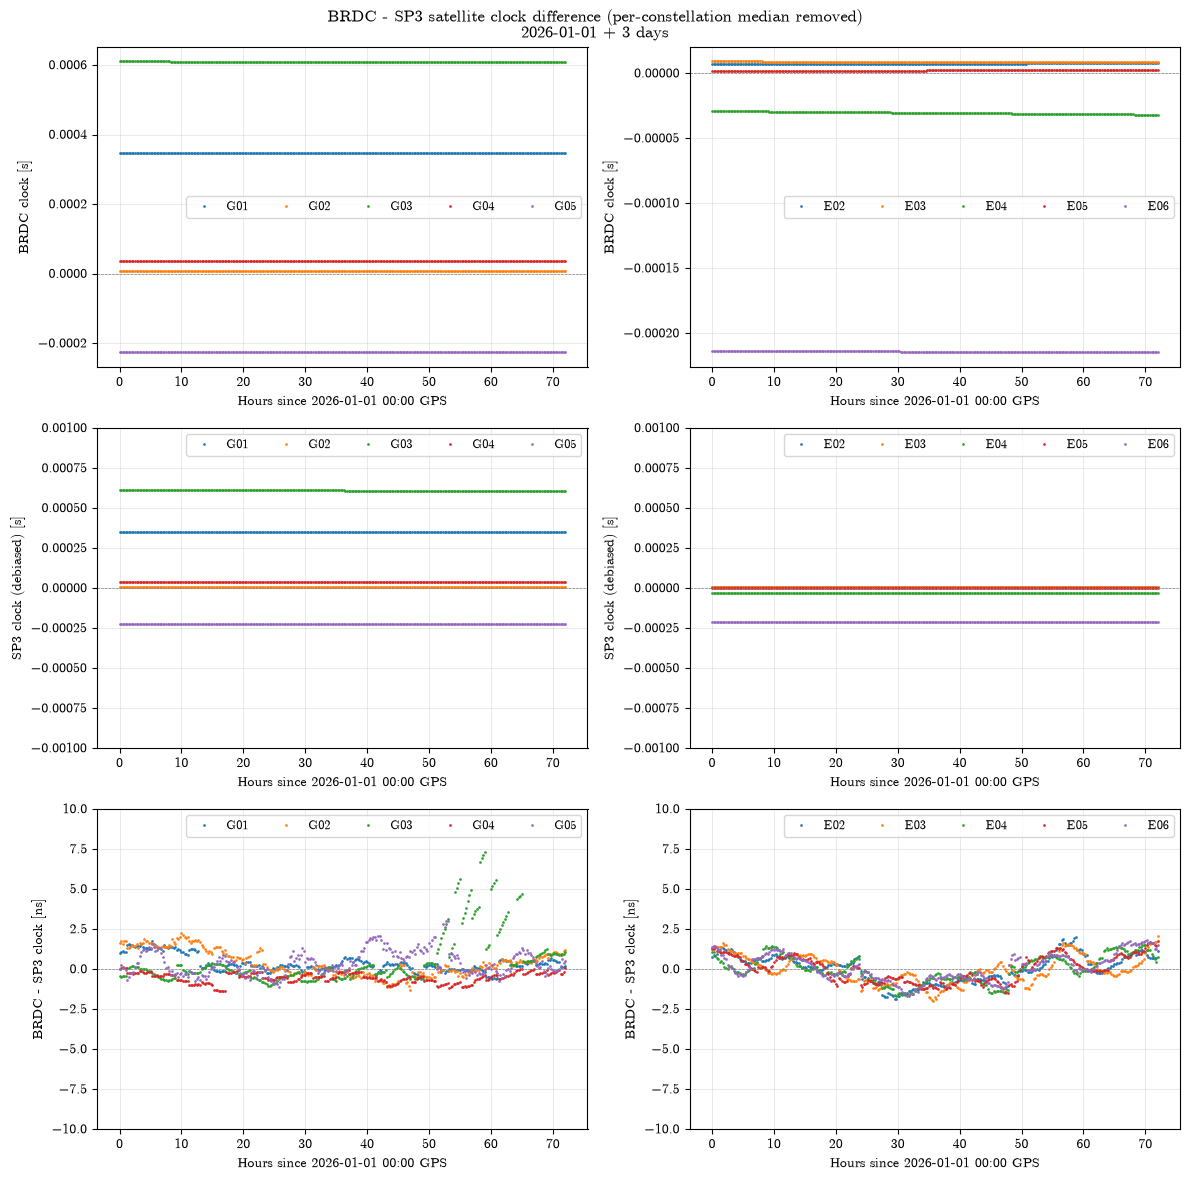


── Orbit & clock accuracy summary ───────────────────────────────────
  PRN   R std [m]   T std [m]   N std [m]   Clk std [ns]
----------------------------------------------------------
  G01        0.14        0.65        0.24           0.51
  G02        0.19        0.59        0.21           0.80
  G03        0.18        0.59        0.25           1.63
  G04        0.14        0.48        0.27           0.32
  G05        0.16        0.58        0.42           0.76
  E02        0.12        0.29        0.11           0.86
  E03        0.16        0.26        0.15           0.86
  E04        0.16        0.35        0.18           0.83
  E05        0.15        0.26        0.12           0.81
  E06        0.14        0.35        0.20           0.83


In [12]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle(
    f"BRDC - SP3 satellite clock difference (per-constellation median removed)\n{days_label}",
    fontsize=12,
)

print(f'\n{"PRN":>5}  {"mean [ns]":>10}  {"std [ns]":>10}  {"peak-to-peak [ns]":>18}')
print("-" * 48)

for row in range(3):
    for col in range(2):
        if col == 0:
            results_items = [
                (tag, d) for tag, d in results.items() if tag.startswith("G")
            ]
        else:
            results_items = [
                (tag, d) for tag, d in results.items() if tag.startswith("E")
            ]

        for i, (tag, d) in enumerate(results_items):
            if row == 0:
                dc_ns = d["clk_brdc"]
                ylabel = "BRDC clock [s]"
            elif row == 1:
                dc_ns = d["clk_sp3"]
                ylabel = "SP3 clock (debiased) [s]"
                ax[row, col].set_ylim(-1e-3, 1e-3)
            else:
                dc_ns = (d["clk_brdc"] - d["clk_sp3"]) * 1e9
                ylabel = "BRDC - SP3 clock [ns]"
                ax[row, col].set_ylim(-10, 10)

            ax[row, col].plot(
                t_hours,
                dc_ns,
                "o",
                lw=0.7,
                color=COLORS[i % len(COLORS)],
                markersize=1,
                label=tag,
                alpha=0.9,
            )
            print(
                f"{tag:>5}  {np.mean(dc_ns):>10.2f}  {np.std(dc_ns):>10.2f}"
                f"  {np.ptp(dc_ns):>18.2f}"
            )

        ax[row, col].set_xlabel(
            f'Hours since {START_DT.strftime("%Y-%m-%d")} 00:00 GPS'
        )
        ax[row, col].set_ylabel(ylabel)
        ax[row, col].axhline(0, color="gray", lw=0.5, ls="--")
        ax[row, col].legend(fontsize=9, ncol=len(results))
        ax[row, col].grid(True, lw=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── Orbit & clock accuracy summary ───────────────────────────────────")
print(
    f'{"PRN":>5}  {"R std [m]":>10}  {"T std [m]":>10}  {"N std [m]":>10}  {"Clk std [ns]":>13}'
)
print("-" * 58)
for tag in results:
    R, T, N = rtn_all[tag]
    dc_ns = (results[tag]["clk_brdc"] - results[tag]["clk_sp3"]) * 1e9
    print(
        f"{tag:>5}  {np.std(R):>10.2f}  {np.std(T):>10.2f}  {np.std(N):>10.2f}"
        f"  {np.std(dc_ns):>13.2f}"
    )

## Error histograms

The histograms pool orbit and clock differences across the selected PRNs and epochs. They provide a compact empirical summary of the broadcast product errors that later measurement simulations must tolerate.

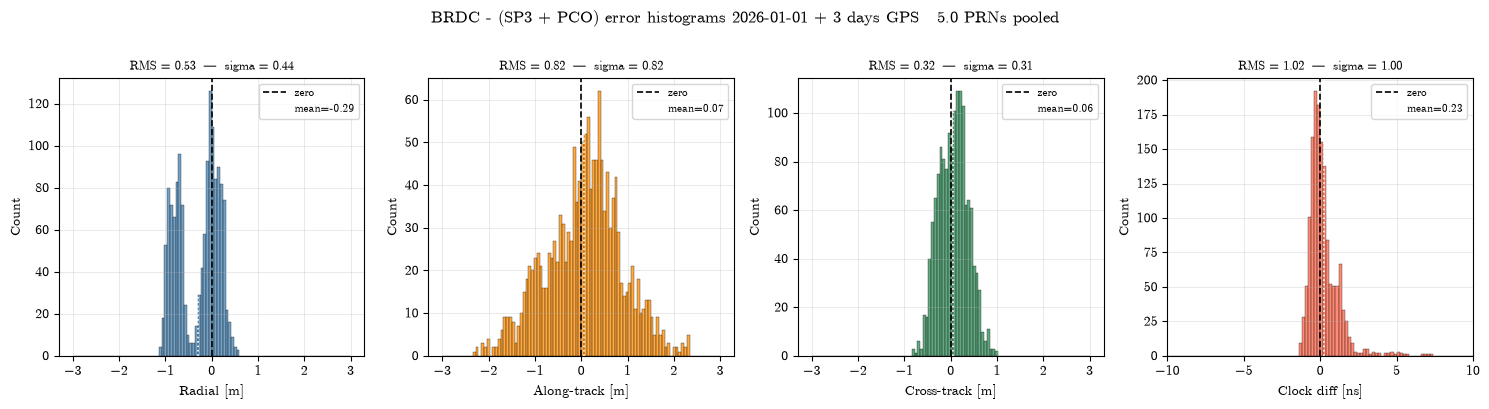

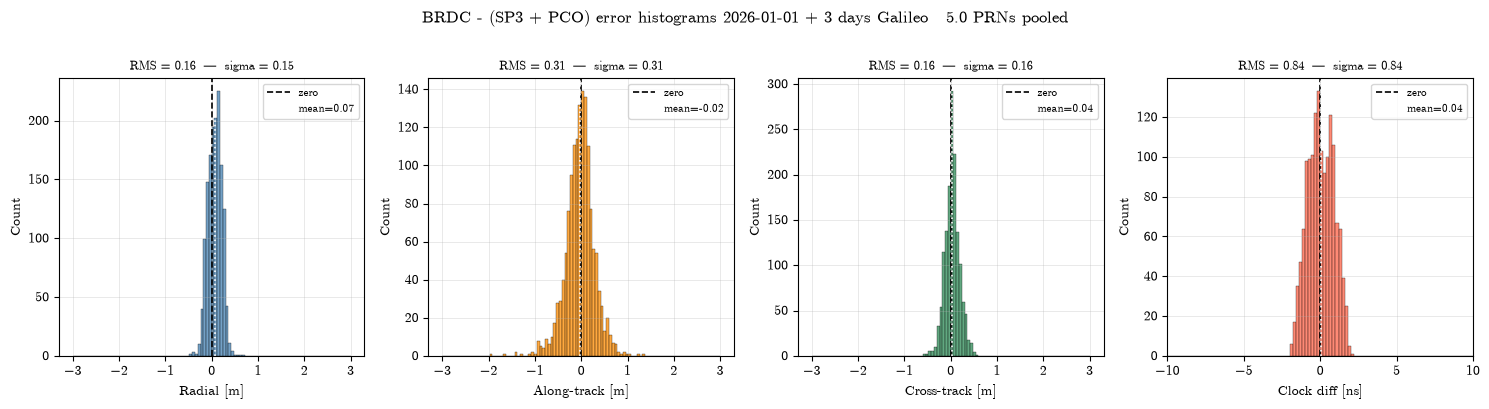

[GPS]

Component                   Mean         Std         RMS    95th pct
------------------------------------------------------------------
Radial [m]                -0.293       0.441       0.529       0.962
Along-track [m]            0.067       0.816       0.819       1.624
Cross-track [m]            0.060       0.315       0.321       0.602
Clock [ns]                 0.227       0.998       1.023       1.747

[Galileo]

Component                   Mean         Std         RMS    95th pct
------------------------------------------------------------------
Radial [m]                 0.069       0.147       0.163       0.296
Along-track [m]           -0.024       0.314       0.314       0.624
Cross-track [m]            0.037       0.159       0.163       0.333
Clock [ns]                 0.039       0.839       0.840       1.542


In [13]:
# Pool errors across all selected PRNs for a global histogram
all_R_gps, all_T_gps, all_N_gps, all_dc_ns_gps = [], [], [], []
all_R_gal, all_T_gal, all_N_gal, all_dc_ns_gal = [], [], [], []

for tag, d in results.items():
    R, T, N = rtn_all[tag]
    if tag.startswith("G"):
        all_R_gps.append(R)
        all_T_gps.append(T)
        all_N_gps.append(N)
        all_dc_ns_gps.append((d["clk_brdc"] - d["clk_sp3"]) * 1e9)
    else:
        all_R_gal.append(R)
        all_T_gal.append(T)
        all_N_gal.append(N)
        all_dc_ns_gal.append((d["clk_brdc"] - d["clk_sp3"]) * 1e9)

pool_R_gps = np.concatenate(all_R_gps)
pool_T_gps = np.concatenate(all_T_gps)
pool_N_gps = np.concatenate(all_N_gps)
pool_clk_gps = np.concatenate(all_dc_ns_gps)

pool_R_gal = np.concatenate(all_R_gal)
pool_T_gal = np.concatenate(all_T_gal)
pool_N_gal = np.concatenate(all_N_gal)
pool_clk_gal = np.concatenate(all_dc_ns_gal)

components_gps = [
    ("Radial [m]", pool_R_gps, "steelblue"),
    ("Along-track [m]", pool_T_gps, "darkorange"),
    ("Cross-track [m]", pool_N_gps, "seagreen"),
    ("Clock diff [ns]", pool_clk_gps, "tomato"),
]
components_gal = [
    ("Radial [m]", pool_R_gal, "steelblue"),
    ("Along-track [m]", pool_T_gal, "darkorange"),
    ("Cross-track [m]", pool_N_gal, "seagreen"),
    ("Clock diff [ns]", pool_clk_gal, "tomato"),
]

bins_pos = np.linspace(-3, 3, 101)
bins_clk = np.linspace(-10, 10, 101)

for row in range(2):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    constellation = "GPS" if row == 0 else "Galileo"
    fig.suptitle(
        f"BRDC - (SP3 + PCO) error histograms {days_label} {constellation} "
        f"  {len(results)/2} PRNs pooled",
        fontsize=12,
        y=1.01,
    )

    for ax, (xlabel, data, color) in zip(
        axes, components_gps if row == 0 else components_gal
    ):
        rms = np.sqrt(np.mean(data**2))
        std = np.std(data)
        mean = np.mean(data)
        ax.hist(
            data,
            bins=bins_pos if xlabel != "Clock diff [ns]" else bins_clk,
            color=color,
            alpha=0.75,
            edgecolor="k",
            lw=0.3,
        )
        ax.axvline(0, color="black", lw=1.2, ls="--", label="zero")
        ax.axvline(mean, color="white", lw=1.2, ls=":", label=f"mean={mean:.2f}")
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.set_title(f"RMS = {rms:.2f}  |  sigma = {std:.2f}", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, lw=0.4, alpha=0.5)
        if xlabel == "Clock diff [ns]":
            ax.set_xlim(-10, 10)

    plt.tight_layout()
    plt.show()

# Numeric summary
print("[GPS]")
print(f'\n{"Component":<20}  {"Mean":>10}  {"Std":>10}  {"RMS":>10}  {"95th pct":>10}')
print("-" * 66)
labels_units = ["Radial [m]", "Along-track [m]", "Cross-track [m]", "Clock [ns]"]
for lbl, data in zip(labels_units, [pool_R_gps, pool_T_gps, pool_N_gps, pool_clk_gps]):
    print(
        f"{lbl:<20}  {np.mean(data):>10.3f}  {np.std(data):>10.3f}"
        f"  {np.sqrt(np.mean(data**2)):>10.3f}  {np.percentile(np.abs(data), 95):>10.3f}"
    )

print("\n[Galileo]")
print(f'\n{"Component":<20}  {"Mean":>10}  {"Std":>10}  {"RMS":>10}  {"95th pct":>10}')
print("-" * 66)
for lbl, data in zip(labels_units, [pool_R_gal, pool_T_gal, pool_N_gal, pool_clk_gal]):
    print(
        f"{lbl:<20}  {np.mean(data):>10.3f}  {np.std(data):>10.3f}"
        f"  {np.sqrt(np.mean(data**2)):>10.3f}  {np.percentile(np.abs(data), 95):>10.3f}"
    )

## Satellite attitude: nominal vs. dedicated yaw steering

GNSS satellites steer their **yaw** (rotation about the nadir axis) so the solar panels track the Sun. LuPNT implements both the standard **nominal** law and block-specific **dedicated** eclipse/noon-turn laws (Cheng et al., 2025; Montenbruck et al., 2026). Reusing the SP3 ECI states and the Sun ephemeris, we turn each law's yaw angle into a body-to-ECI triad (`GnssAttitude.compute_from_yaw_angle`) and read off the body-frame Euler angles for a representative GPS and Galileo satellite.

The dedicated law only departs from the nominal one during a **yaw maneuver** — near orbit noon/midnight at **low Sun elevation** (small `|β|`), where the nominal yaw rate would exceed the spacecraft's hardware limit. Away from that (which is almost the whole year for any given satellite — `|β| ≳ 5.8°` for GPS III), the rate-limited law reduces *exactly* to nominal, so the two curves below **coincide**. That flat difference is the expected result for a satellite that is not currently in its eclipse season. The next cell confirms this from the satellite's own `β`, then constructs a synthetic low-`β` noon/midnight turn to show how the laws actually differ — and how they differ **between GPS blocks** (IIR/IIR-M at 0.20°/s, IIF at 0.11°/s, and the smoothly rate-limited III).

/tmp/ipykernel_10154/55578966.py:82: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) cmr10.
  plt.tight_layout()
/path/to/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


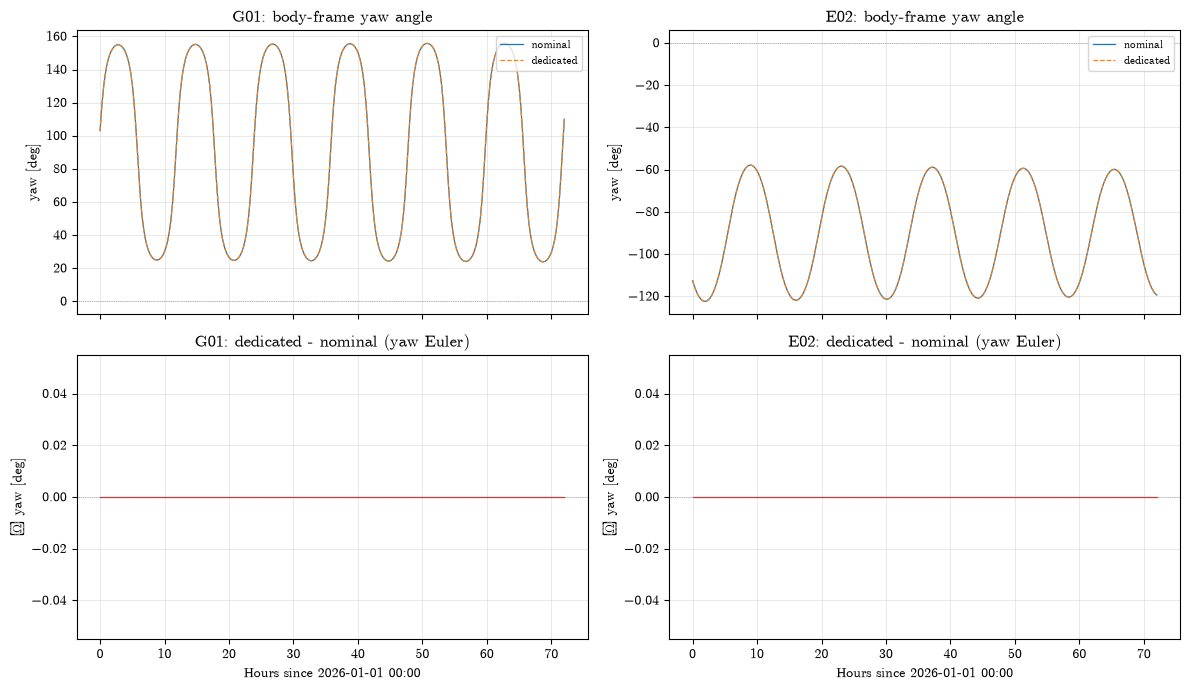

In [14]:
# ── Body-frame attitude: nominal vs dedicated yaw steering ────────────────────
def _sun_eci(t_tdb_arr):
    return np.array(
        [
            np.asarray(
                pnt.get_body_pos_vel(
                    float(t), pnt.BodyId.SUN, pnt.BodyId.EARTH, pnt.ECI
                )
            )[:3]
            for t in t_tdb_arr
        ]
    )


def attitude_curves(rv_eci, r_sun, dedicated_law):
    r, v = rv_eci[:, :3], rv_eci[:, 3:]
    n = len(r)
    yaw = np.zeros((n, 2))  # [nominal, dedicated]  (rad)
    rpy_nom = np.zeros((n, 3))  # roll/pitch/yaw Euler of the body triad (deg)
    rpy_ded = np.zeros((n, 3))
    for k in range(n):
        if not np.all(np.isfinite(rv_eci[k])):
            yaw[k] = np.nan
            rpy_nom[k] = np.nan
            rpy_ded[k] = np.nan
            continue
        beta = float(pnt.GnssYawSteering.beta_angle(r[k], v[k], r_sun[k]))
        mu = float(pnt.GnssYawSteering.orbit_angle(r[k], v[k], r_sun[k]))
        phi_n = float(pnt.GnssYawSteering.nominal_yaw_angle(beta, mu))
        phi_d = float(dedicated_law(beta, mu, phi_n))
        yaw[k] = [phi_n, phi_d]
        Rn = np.column_stack(
            [
                np.asarray(a)
                for a in pnt.GnssAttitude.compute_from_yaw_angle(r[k], v[k], phi_n)
            ]
        )
        Rd = np.column_stack(
            [
                np.asarray(a)
                for a in pnt.GnssAttitude.compute_from_yaw_angle(r[k], v[k], phi_d)
            ]
        )
        rpy_nom[k] = np.degrees(np.asarray(pnt.rot_to_roll_pitch_yaw(Rn)))
        rpy_ded[k] = np.degrees(np.asarray(pnt.rot_to_roll_pitch_yaw(Rd)))
    return yaw, rpy_nom, rpy_ded


r_sun_eci = _sun_eci(t_q_tdb)
gps_tag = f"G{COMMON_PRNS_GPS[0]:02d}"
gal_tag = f"E{COMMON_PRNS_GAL[0]:02d}"
# GPS: Block-III eclipse law; Galileo: IOV eclipse law (needs the noon-referenced orbit angle).
gps = attitude_curves(
    results[gps_tag]["rv_sp3"],
    r_sun_eci,
    lambda b, m, p: pnt.GnssYawSteering.gps3_eclipse_yaw_angle(b, m, p),
)
gal = attitude_curves(
    results[gal_tag]["rv_sp3"],
    r_sun_eci,
    lambda b, m, p: pnt.GnssYawSteering.galileo_iov_eclipse_yaw_angle(
        pnt.GnssYawSteering.orbit_noon_angle(m), b, p
    ),
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for col, (tag, (yaw, rpy_nom, rpy_ded)) in enumerate([(gps_tag, gps), (gal_tag, gal)]):
    axes[0, col].plot(t_hours, np.degrees(yaw[:, 0]), lw=0.9, label="nominal")
    axes[0, col].plot(
        t_hours, np.degrees(yaw[:, 1]), lw=0.9, ls="--", label="dedicated"
    )
    axes[0, col].set_title(f"{tag}: body-frame yaw angle")
    axes[0, col].set_ylabel("yaw [deg]")
    axes[0, col].legend(fontsize=8, loc="upper right")
    axes[1, col].plot(t_hours, rpy_ded[:, 2] - rpy_nom[:, 2], lw=0.9, color="tab:red")
    axes[1, col].set_title(f"{tag}: dedicated - nominal (yaw Euler)")
    axes[1, col].set_ylabel("Δ yaw [deg]")
    axes[1, col].set_xlabel(f"Hours since {START_DT.strftime('%Y-%m-%d')} 00:00")
for a in axes.ravel():
    a.grid(True, lw=0.4, alpha=0.5)
    a.axhline(0, color="gray", lw=0.5, ls=":")
plt.tight_layout()
plt.show()

G01 |beta| over this arc: 23.8-25.1 deg -> outside the GPS III eclipse regime (|beta| < 5.8 deg), so every dedicated law
reduces exactly to nominal (no maneuver -> the difference above is zero). Below we sweep a synthetic low-beta turn to show the block laws differ:


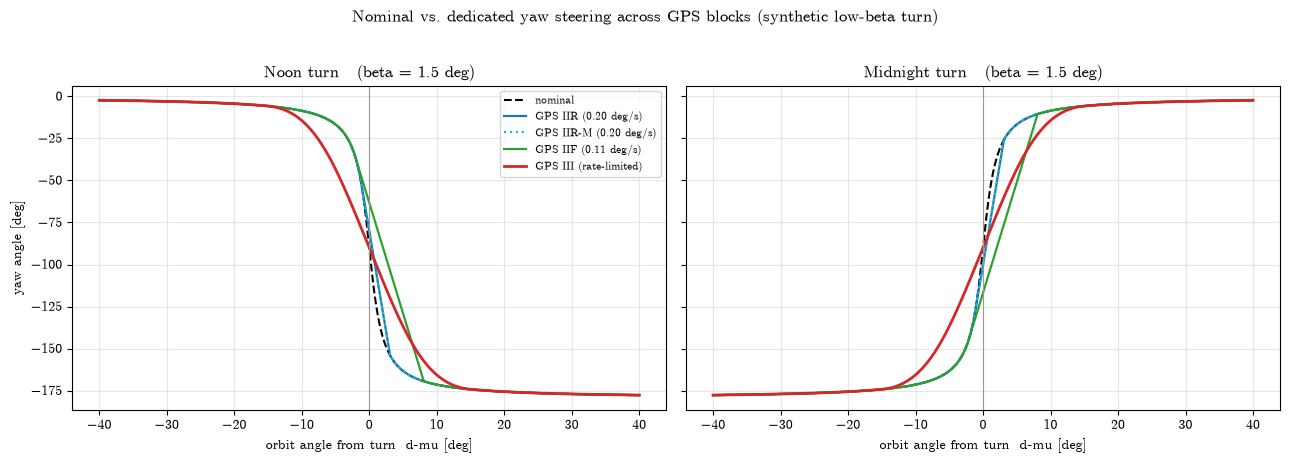

In [15]:
# ── Why the plot above is flat, and how the block laws differ (synthetic turn) ─
# The dedicated (rate-limited) law leaves nominal only during a yaw maneuver -- near orbit
# noon/midnight at LOW Sun elevation |beta|. Confirm the representative GPS satellite's beta:
_valid = [
    k
    for k in range(len(r_sun_eci))
    if np.all(np.isfinite(results[gps_tag]["rv_sp3"][k]))
]
_beta = np.degrees(
    [
        float(
            pnt.GnssYawSteering.beta_angle(
                results[gps_tag]["rv_sp3"][k, :3],
                results[gps_tag]["rv_sp3"][k, 3:],
                r_sun_eci[k],
            )
        )
        for k in _valid
    ]
)
print(
    f"{gps_tag} |beta| over this arc: {abs(_beta).min():.1f}-{abs(_beta).max():.1f} deg "
    f"-> outside the GPS III eclipse regime (|beta| < 5.8 deg), so every dedicated law\n"
    f"reduces exactly to nominal (no maneuver -> the difference above is zero). Below we sweep "
    f"a synthetic low-beta turn to show the block laws differ:"
)

Y = pnt.GnssYawSteering
d2r, r2d = np.radians, np.degrees
MU_DOT = 2 * np.pi / 43080.0  # GPS mean orbital rate [rad/s]


def _nominal(beta, mu):
    return np.arctan2(-np.tan(beta), np.sin(mu))


def _rate_limited(mu, beta, rate_deg_s):
    # Cap the yaw slew at the block's hardware rate -- reproduces LuPNT's constant-rate GPS
    # IIR/IIF noon/midnight-turn laws (follow nominal, ramp at the limit, then catch up).
    t = mu / MU_DOT
    phin = np.unwrap(_nominal(beta, mu))
    phi = phin.copy()
    cap_rate = d2r(rate_deg_s)
    for k in range(1, len(mu)):
        cap = cap_rate * (t[k] - t[k - 1])
        phi[k] = phi[k - 1] + np.clip(phin[k] - phi[k - 1], -cap, cap)
    return phi


def _gps3(mu, beta):
    return np.array(
        [Y.gps3_eclipse_yaw_angle(beta, m, Y.nominal_yaw_angle(beta, m)) for m in mu]
    )


BETA = d2r(1.5)  # small Sun elevation -> a real yaw maneuver
# GPS blocks with a yaw-steering law: IIR / IIR-M share the 0.20 deg/s constant-rate turn,
# IIF uses 0.11 deg/s, and III is smoothly rate-limited (Montenbruck et al., 2026).
BLOCKS = [
    ("IIR", 0.20, "tab:blue", "-"),
    ("IIR-M", 0.20, "tab:cyan", ":"),
    ("IIF", 0.11, "tab:green", "-"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (title, mu0) in zip(axes, [("Noon turn", np.pi), ("Midnight turn", 0.0)]):
    dmu = d2r(np.linspace(-40, 40, 4001))
    mu = mu0 + dmu
    ax.plot(
        r2d(dmu), r2d(np.unwrap(_nominal(BETA, mu))), "k--", lw=1.5, label="nominal"
    )
    for name, rate, color, ls in BLOCKS:
        ax.plot(
            r2d(dmu),
            r2d(_rate_limited(mu, BETA, rate)),
            color=color,
            ls=ls,
            lw=1.6,
            label=f"GPS {name} ({rate:.2f} deg/s)",
        )
    ax.plot(
        r2d(dmu),
        r2d(np.unwrap(_gps3(mu, BETA))),
        color="tab:red",
        lw=2.0,
        label="GPS III (rate-limited)",
    )
    ax.axvline(0.0, color="0.6", lw=0.8)
    ax.set_xlabel("orbit angle from turn  d-mu [deg]")
    ax.set_title(f"{title}   (beta = {r2d(BETA):.1f} deg)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("yaw angle [deg]")
axes[0].legend(loc="best", fontsize=8)
fig.suptitle(
    "Nominal vs. dedicated yaw steering across GPS blocks (synthetic low-beta turn)",
    y=1.02,
)
plt.tight_layout()
plt.show()